# Normal Distribution, Sampling & Confidence
#####    Practical assignment 2

This practical assignment need to be handed in on Brightspace before the deadline, 16:00 24/04/2021. Make sure that every cell is executed/compiled and renamed to

**Assignment2_Surname1_Surname2.ipynb**

before submitting. For questions contact your TA during the workgroup, or via mail. Depending on whether all questions are sufficiently answered and if enough effort has been put into the assignment, you wil get good (all questions answered and all topics underestood well), sufficient (enough effort has been put but need to learn more and underestand better) or fail (not enough effort has been put into this assignment).

**Name 1:** Feliks Lysiuk - s1125187

**Name 2:** Angelina Podolako - s1125886

### Dataset

Breakout is a fun game to play, where you control a small paddle that can move sideways on the bottom of the screen, where the goal is to bounce a ball back upwards against placed bricks. Each brick that is broken awards the player with some points. When all bricks are cleared, the player advances to the next level. Whenever the ball is not bounced back the player loses 1 life and can try again in the same level. When all lives are lost, the game is over.

Two friends play this game simultaneously, and define winning as having a higher score than the other person. All the games these two friends ever played together are collected in this dataset.

Let's start by loading the toolboxes we need and uploading the dataset.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_style("whitegrid")


In [8]:
# needed/convenient only  if you're working in Google colab (not for local Jupyter)
from google.colab import files
uploaded = files.upload()

Saving Breakout.csv to Breakout.csv


In [9]:
breakout_score = pd.read_csv("Breakout.csv")
breakout_score.keys()

Index(['score_1', 'wins_1', 'score_2', 'wins_2'], dtype='object')

In this workgroup, we will focus only on the scores of player 1. Which you can find in the variable score_1. Each row represents the score of one game.

### <span style="color:red"> Question 1 </span>
How often did this player play the game?

In [10]:
total = len(breakout_score)
print(total)

1000


### Normal distribution

Before we are going to analyze the data, it is important to see how the data is distributed, or more importantly, if it is normally distributed or not.

### <span style="color:red"> Question 2 </span>
Plot the distributions of the scores of this player, and describe the distribution. Do you think the data are normally distributed? (hint: use a distplot)

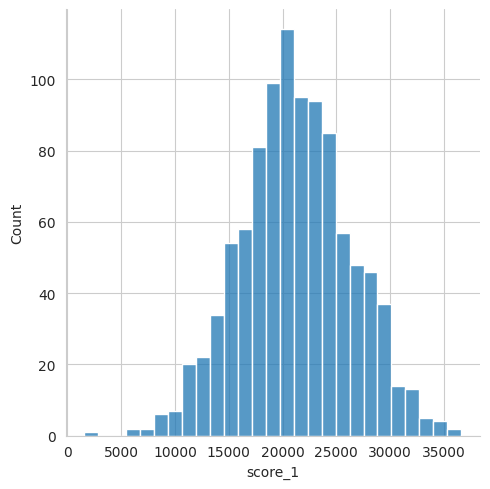

In [11]:
sns.displot(breakout_score['score_1'])

The distribution shows the number of times when the specific range of points was acquired (e.x. 30000-35000 of points were achieved around 40 times out of 1000 games.)  
The data are normally distributed, but is not fully symmetric.

### Normal probability

Once we decide that a variable is approximately normal, we can use our knowledge about the normat distribution to answer all sorts of questions about that variable related to probability. Take, for example, the question of, "What is the probability that this player scores 20000 or lower in a particular game?"

To answer this question, we compute the z-score, which tells us something about how far a datapoint is from the mean. Then we use a z-table to convert this z-score to a probability.

In Python, this is done in one step with the function stats.norm.cdf().

In [12]:
mean = breakout_score['score_1'].mean()
std = breakout_score['score_1'].std()
score = 20000

norm.cdf(score, mean, std)

0.4075083828254094

This means that this player has a probability of 0.408 of having a score lower than 20000.

We can compare that probability to the empirical probability. We simply need to determine how many observations fall below 20000 then divide this number by the total sample size.

In [13]:
n_below_20000 = (breakout_score['score_1'] < score).sum()

empirical_probability=(n_below_20000 / total)
print(empirical_probability)

0.4



Although the probabilities are not exactly the same, they are reasonably close. The closer that your distribution is to being normal, the more accurate the theoretical probabilities will be.

### <span style="color:red"> Question 3 </span>

The average score of all players online is 21500. What is the probability that in a particular game, this player scores higher than this online average? Use the normal approximation to compute this probability.

In [14]:
global_average = 21500
normal_approx = 1 - (norm.cdf(21500, loc=mean, scale=std))
print(normal_approx)

0.47675685382010213


### Sampling

In this lab we have access to the entire population, but this is rarely the case in real life. Gathering information on an entire population is often extremely costly or impossible. Because of this, we often take a sample of the population and use that to understand the properties of the population.

We can use the following command to sample 30 observations from the population:

In [15]:
samp = breakout_score['score_1'].sample(30)

### <span style="color:red"> Question 4.1 </span>
Have a look at the distribution of the sampled data by making another distplot. Describe how it differs from the population distribution. And how does that change when you draw a larger sample of 100 scores?



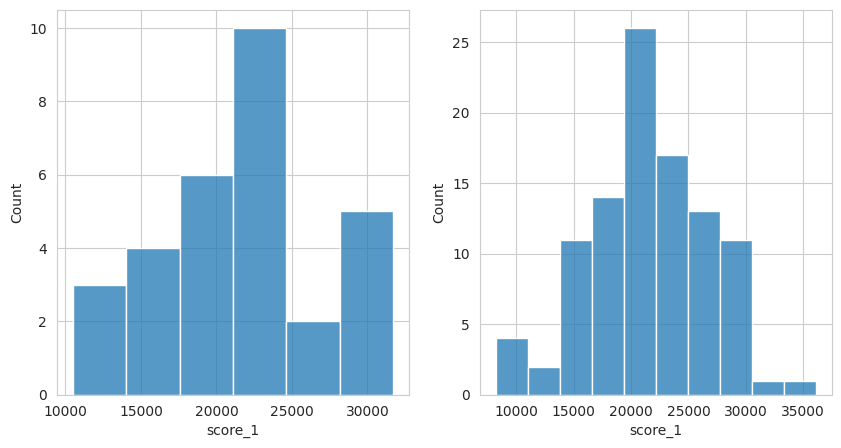

In [34]:
samp2 = breakout_score['score_1'].sample(100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(samp, ax=ax1)
sns.histplot(samp2, ax=ax2)

plt.show()


 The sample of data from the number 30 did not include some pieces of information.

Now the graph includes a larger range of points, and the graph is more similar to a normally distributed one. Previously, it was more shifted to the right.
The frequency (which is not surprising) of each event has also increased

### <span style="color:red"> Question 4.2 </span>
Let's recompute our estimate for the probability that in a particular game, this player scores higher than the online average. Does the probability differ from the probability observed in the population? Which sample estimate (30 or 100 participants) is closer to the population estimate?

In [35]:
population_proportion = (breakout_score['score_1'] > global_average).mean()
sample_proportion_30 = (samp > global_average).mean()
sample_proportion_100 = (samp2 > global_average).mean()

print(population_proportion)
print(sample_proportion_30)
print(sample_proportion_100)

0.458
0.5
0.46


Probabilities calculated on the basis of samples do not differ much from the probability of the general population. The estimate of the probability that in a particular game this player will score more points than the network average: in the aggregate is 0.458, while the proportion of the sample of 30 participants and 100 participants is 0.5 and 0.46, respectively.

Both sample estimates are close to the estimate of the population, but the estimate for a sample of 100 participants (0.46) is closer to the estimate of the population (0.458) (the difference is only 0.002) compared with the estimate for a sample of 30 participants (0.5)(the difference is only 0.042). However, in both cases, the difference between the sample estimates and the aggregate estimate is relatively small.

Every time we take another random sample, we get a different distribution and a different estimate.   It's useful to get a sense of just how much variability we should expect when estimating the population proportion this way. The distribution of sample probabilities, called the sampling distribution, can help us understand this variability. We can build up the sampling distribution for the population proportion by repeating the above steps many times.

### <span style="color:red"> Question 4.3 </span>

Create 5000 samples of size 30 and size 100 of the players' scores.
For each sample, compute the probability under the normal distribution that this player outperforms the average player (hint, make some empty numpy arrays and fill those with values in your for loop). Save the values in each sample and show them in a histogram (you can use the distplot again). Make one histogram per sample size and make sure the x-axes are equal. How do the center and the spread of your sample distribution change when your sample size increases?

<Axes: ylabel='Count'>

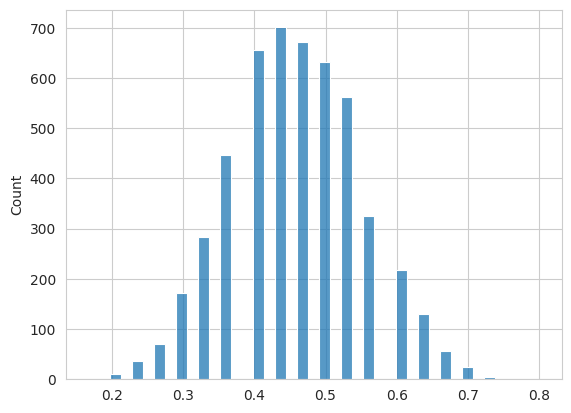

In [18]:
sample_probabilities_30 = np.empty(5000)

# Generating 5000 samples of size 30
for i in range(5000):
    sample = np.random.choice(breakout_score['score_1'], size=30)
    sample_probabilities_30[i] = np.mean(sample > global_average)

sns.histplot(sample_probabilities_30)

<Axes: ylabel='Count'>

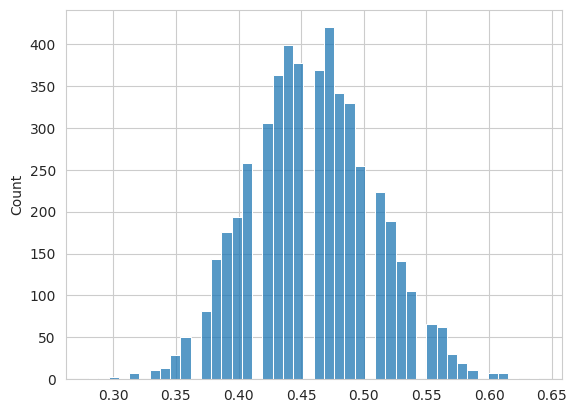

In [19]:
sample_probabilities_100 = np.empty(5000)

# Generating 5000 samples of size 100
for i in range(5000):
    sample = np.random.choice(breakout_score['score_1'], size=100)
    sample_probabilities_100[i] = np.mean(sample > global_average)

sns.histplot(sample_probabilities_100)


The center of the sample (30) is approximately at 0.475, and the center of the sample (100) is 0.45. That is, there was a slight shift to the left.

both graphs are normally distributed, but a graph with 30 samples captures a larger number along the x axis and y. That is, it is distributed wider and higher, although the graph with samples out of 100 is more dense, since it contains more data.

### Confidence intervals

Let's say we want to know what the average performance of our player is. If we have access to data on an entire population, it is straightforward to answer questions like this. When we only have sample data, we can approximate the mean of our population using our sample mean. That serves as a good point estimate but it would be useful to also communicate how uncertain we are of that estimate. This can be captured by using a confidence interval.

In the online lecture, you have seen how to calculate a confidence interval for probabilities. We can use a similar method to compute a confidence interval for numerical data. We can calculate a 95% confidence interval for a sample mean by adding and subtracting 1.96 standard errors to the point estimate (this is the z*–value). By computing confidence intervals, we can make inferences about what the population means. For numerical data, we can compute the standard error using the formula: SE = S/sqrt(n)


### <span style="color:red"> Question 5.1 </span>

Write a function that takes a sample dataset and a z*–value as input and that outputs the lower and the upper bound of the confidence interval.
(use google if you don't know yet how to write a function in Python)

In [20]:
def confidence_interval(sample, z_value ):
    """
    Calculate the 95% confidence interval for the mean of a sample dataset.

    Parameters:
        sample (array-like): The sample dataset.
        z_value (float): The z*–value corresponding to the desired confidence level.

    Returns:
        tuple: A tuple containing the lower and upper bounds of the confidence interval.
    """
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    sample_size = len(sample)
    standard_error = sample_std / np.sqrt(sample_size)

    lower_bound = sample_mean - z_value * standard_error
    upper_bound = sample_mean + z_value * standard_error

    return lower_bound, upper_bound

### <span style="color:red"> Question 5.2 </span>

Draw a sample of 30 scores and print the confidence interval. Does the confidence interval contain the population mean?

In [36]:
sample_30_random = np.random.choice(breakout_score['score_1'], size=30)

conf_interval_30 = confidence_interval(sample_30_random, 1.96)  # Assuming z-value of 1.96 for 95% confidence level
print(conf_interval_30)

(18594.06828110051, 21765.93171889949)


The population mean is represented by global_average and is 21500. The confidence interval is (18594.06828110051, 21765.93171889949).

As 21500 > 18594 and 21500 < 21766, The population mean is included in confidence interval.

### <span style="color:red"> Question 5.3 </span>
Now recompute the confidence interval for a sample of 200 scores. How does the interval change? Why is that?


In [22]:
sample_200_random = np.random.choice(breakout_score['score_1'], size=200)

conf_interval_200 = confidence_interval(sample_200_random, 1.96)  # Assuming z-value of 1.96 for 95% confidence level
print(conf_interval_200)

(19887.324725373175, 21150.675274626825)


The confidence interval for a sample of 200 points is narrower than the confidence interval for a sample of 30 points.
The interval for a sample of 200 points is (19887.324725373175, 21150.675274626825), while
The interval for a sample of 30 points is (18594.06828110051, 21765.93171889949).

The lower bound rose by 1293 (that is, it narrowed by this value), and the upper bound fell by 615 (that is, it narrowed by this value). In general, the sample has already become 1908 (-1293-615= -1908).

### <span style="color:red"> Question 5.4 </span>
Now change the confidence level to 99% (z*=2.58) for the 200 samples. How does that change your interval?

In [37]:
sample_200_random = np.random.choice(breakout_score['score_1'], size=200)

conf_interval_200_99_percent = confidence_interval(sample_200_random, 2.58)  # Assuming z-value of 2.58 for  99% confidence level
print(conf_interval_200_99_percent)

(19710.462001867225, 21616.537998132775)



Changing the confidence level by 99% (z*=2.58) for a sample of 200 points leads to a wider confidence interval compared to the interval calculated with a confidence level of 95%. That is, the confidence interval for the 99% confidence level is (19710.462001867225, 21616.537998132775), while the interval for the 95% confidence level is (19887.324725373175, 21150.675274626825).

To maintain a higher level of confidence, the interval should be wider to cover most of the sample distribution. As a result, the interval becomes wider, which provides a higher level of confidence in estimating the true parameter of the population.

### <span style="color:red"> Question 5.5 </span>
Draw 5000 samples of 50 scores and count how often the 95% confidence interval contains the population mean. Is this number similar to what you would expect?

In [24]:
sample_probabilities_50 = np.empty(5000)
contains_population_mean = []

# Generating 5000 samples of size 50
for i in range(5000):
    sample_probabilities_50 = np.random.choice(breakout_score['score_1'], size=50, replace=True)
    conf_interval_5000 = confidence_interval(sample_probabilities_50, 1.96)

    # Check if the confidence interval contains the population mean
    if conf_interval_5000[0] <= global_average <= conf_interval_5000[1]:
        contains_population_mean.append(1)  # If yes, append 1 to the list
    else:
        contains_population_mean.append(0)  # If no, append 0 to the list

# Count how many times the confidence interval contains the population mean
count_contain_population_mean = sum(contains_population_mean)
print(count_contain_population_mean)

# Calculate the proportion of times the confidence interval contains the population mean
proportion_contain_population_mean = count_contain_population_mean / 5000
print(proportion_contain_population_mean)


4638
0.9276


The number of cases where the 95% confidence interval corresponds to the average value for the population is 0.9276. In other words, out of 5,000 samples of 50 points each, the confidence interval corresponded to the average value in the aggregate in about 92.76% of cases.

This result is quite close to the expected one. Theoretically, at a confidence level of 95%, we expect that the confidence interval will contain an average value for the population of about 95% of the samples, if our assumptions are correct. A slight deviation from the expected 95% may be caused by a random sample.